In [2]:
import pandas as pd

# Online Retail II ships as an Excel file with two sheets — one per year
df_2009_2010 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2009-2010')
df_2010_2011 = pd.read_excel('../data/raw/online_retail_II.xlsx', sheet_name='Year 2010-2011')

print(df_2009_2010.shape) # comfirms how much data we're working with
print(df_2010_2011.shape)
df_2009_2010.head()

(525461, 8)
(541910, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Combine both years into one dataframe for full analysis
df = pd.concat([df_2009_2010, df_2010_2011], ignore_index=True)
print("Total rows:", df.shape[0])

# Check 1 : How many rows have missing customer ID?
print("Missing Customer ID:", df['Customer ID']. isna().sum())
# Check 2 : How many invoices are cancellations (Invoice Starting with 'C')?
Cancellations = df[df['Invoice']. astype(str).str.startswith('C')]
print("Cancellation rows:", Cancellations.shape[0])
# Check 3 : How many rows have negative Quantity (Likely returns)?
print("Negative quantity rows:", (df['Quantity'] < 0).sum())

Total rows: 1067371
Missing Customer ID: 243007
Cancellation rows: 19494
Negative quantity rows: 22950


## Apply the customer-level filter and confirm the resulting dataset size

In [4]:
# Customer-level analysis requires a known Customer ID
df_customers = df.dropna(subset = ['Customer ID']).copy()
df_customers['Customer ID'] = df_customers['Customer ID'].astype(int)
print("Rows after dropping missing Customer ID:", df_customers.shape[0])
print("Unique customers:", df_customers['Customer ID'].nunique())

Rows after dropping missing Customer ID: 824364
Unique customers: 5942


## calculate line-level revenue first


In [5]:
df_customers['LineRevenue'] = df_customers['Quantity'] * df_customers['Price']
df_customers[['Quantity', 'Price', 'LineRevenue']].head()

,Quantity,Price,LineRevenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [6]:
import datetime as dt

# "Today" for recency purposes = one day after the last transaction in the dataset
snapshot_date = df_customers['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_customers.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('LineRevenue', 'sum')
).reset_index()

rfm.head(10)

,Customer ID,Recency,Frequency,Monetary
0,12346,326,17,-64.68
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,5,4404.54
4,12350,310,1,334.40
5,12351,375,1,300.93
6,12352,36,13,1889.21
7,12353,204,2,406.76
8,12354,232,1,1079.40
9,12355,214,2,947.61


In [7]:
print("Customers with Monetary <= 0:", (rfm['Monetary'] <= 0).sum())
print("Percent of total customers:", round((rfm['Monetary'] <= 0).sum() / len(rfm) * 100, 2), "%")

Customers with Monetary <= 0: 100
Percent of total customers: 1.68 %


In [8]:
rfm_clv = rfm[rfm['Monetary'] > 0].copy()
print("Customers included in CLV analysis:", len(rfm_clv))

Customers included in CLV analysis: 5842


In [9]:
# Score each metric into quartiles (1=worst, 4=best)
# Recency is reversed: LOWER days-since-purchase = BETTER, so we flip the scoring
rfm_clv['R_Score'] = pd.qcut(rfm_clv['Recency'], 4, labels=[4,3,2,1]).astype(int)
rfm_clv['F_Score'] = pd.qcut(rfm_clv['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)
rfm_clv['M_Score'] = pd.qcut(rfm_clv['Monetary'], 4, labels=[1,2,3,4]).astype(int)

rfm_clv['RFM_Score'] = rfm_clv['R_Score'] + rfm_clv['F_Score'] + rfm_clv['M_Score']

rfm_clv[['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10)

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1,12347,2,8,5633.32,4,3,4,11
2,12348,75,5,2019.40,3,3,3,9
3,12349,19,5,4404.54,4,3,4,11
4,12350,310,1,334.40,2,1,1,4
5,12351,375,1,300.93,2,1,1,4
6,12352,36,13,1889.21,3,4,3,10
7,12353,204,2,406.76,2,1,2,5
8,12354,232,1,1079.40,2,1,3,6
9,12355,214,2,947.61,2,1,3,6
10,12356,23,6,6373.68,4,3,4,11


In [10]:
def segment_customer(row):
    if row['RFM_Score'] >= 10:
        return 'Champions'
    elif row['RFM_Score'] >= 8:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3 and row['RFM_Score'] < 8:
        return 'Recent but Low Value'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk (Was Valuable)'
    elif row['RFM_Score'] <= 4:
        return 'Lost'
    else:
        return 'Needs Attention'

rfm_clv['Segment'] = rfm_clv.apply(segment_customer, axis=1)

rfm_clv['Segment'].value_counts()

Segment
Champions                 1722
Loyal Customers           1174
Lost                      1133
Needs Attention            864
Recent but Low Value       621
At Risk (Was Valuable)     328
Name: count, dtype: int64

In [11]:
rfm_clv.to_csv('../data/processed/rfm_segments.csv', index=False)

In [12]:
# CLV here = historical total revenue per customer (already calculated as 'Monetary')
clv_ranked = rfm_clv[['Customer ID', 'Monetary']].sort_values('Monetary', ascending=False).reset_index(drop=True)
clv_ranked['CLV_Rank'] = clv_ranked.index + 1

total_revenue = clv_ranked['Monetary'].sum()
clv_ranked['Pct_of_Total'] = round(100 * clv_ranked['Monetary'] / total_revenue, 2)
clv_ranked['Cumulative_Pct'] = clv_ranked['Pct_of_Total'].cumsum()

# The key business question: what % of customers drive 80% of revenue?
top_20pct_count = int(len(clv_ranked) * 0.2)
revenue_from_top_20pct = clv_ranked.iloc[:top_20pct_count]['Pct_of_Total'].sum()

print(f"Top 20% of customers ({top_20pct_count} customers) generate {round(revenue_from_top_20pct, 1)}% of total revenue")
clv_ranked.head(10)


Top 20% of customers (1168 customers) generate 76.8% of total revenue


,Customer ID,Monetary,CLV_Rank,Pct_of_Total,Cumulative_Pct
0,18102,598215.22,1,3.57,3.57
1,14646,523342.07,2,3.13,6.70
2,14156,296564.69,3,1.77,8.47
3,14911,270248.53,4,1.61,10.08
4,17450,233579.39,5,1.40,11.48
5,13694,190825.52,6,1.14,12.62
6,17511,171885.98,7,1.03,13.65
7,12415,143269.29,8,0.86,14.51
8,16684,141502.25,9,0.85,15.36
9,15061,136391.48,10,0.81,16.17


In [13]:
clv_ranked.to_csv('../data/processed/clv_ranked.csv', index=False)

In [14]:
df_customers['InvoiceMonth'] = df_customers['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_customers.groupby('InvoiceMonth')['LineRevenue'].sum().reset_index()
monthly_revenue['InvoiceMonth'] = monthly_revenue['InvoiceMonth'].dt.to_timestamp()

print(monthly_revenue.shape)
monthly_revenue


(25, 2)


,InvoiceMonth,LineRevenue
0,2009-12-01,663272.050
1,2010-01-01,531952.902
2,2010-02-01,489399.586
3,2010-03-01,635996.481
4,2010-04-01,560635.022
5,2010-05-01,559924.550
6,2010-06-01,571459.910
7,2010-07-01,562785.900
8,2010-08-01,587256.460
9,2010-09-01,781033.301


In [15]:
print("Last transaction date in dataset:", df_customers['InvoiceDate'].max())

Last transaction date in dataset: 2011-12-09 12:50:00


In [16]:
# Exclude the partial final month before forecasting
monthly_revenue_full = monthly_revenue[monthly_revenue['InvoiceMonth'] < '2011-12-01'].copy()
print(monthly_revenue_full.shape)
monthly_revenue_full.tail()

(24, 2)


,InvoiceMonth,LineRevenue
19,2011-07-01,574238.481
20,2011-08-01,616368.000
21,2011-09-01,931440.372
22,2011-10-01,974603.590
23,2011-11-01,1132407.740


 The final month (December 2011) contains only 9 days of transactions 
  (data collection ended December 9, 2011), not a full month. This 
  partial month was excluded from time-series forecasting to avoid the 
  model misinterpreting incomplete data as a genuine December collapse.

In [17]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

ts = monthly_revenue_full.set_index('InvoiceMonth')['LineRevenue']

model = ExponentialSmoothing(ts, trend='add', seasonal='add', seasonal_periods=12)
fitted_model = model.fit()

forecast = fitted_model.forecast(3)
print(forecast)

2011-12-01    884594.959059
2012-01-01    503140.051513
2012-02-01    463431.856937
Freq: MS, dtype: float64


C:\Users\Administrator\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


# actual vs. forecast together

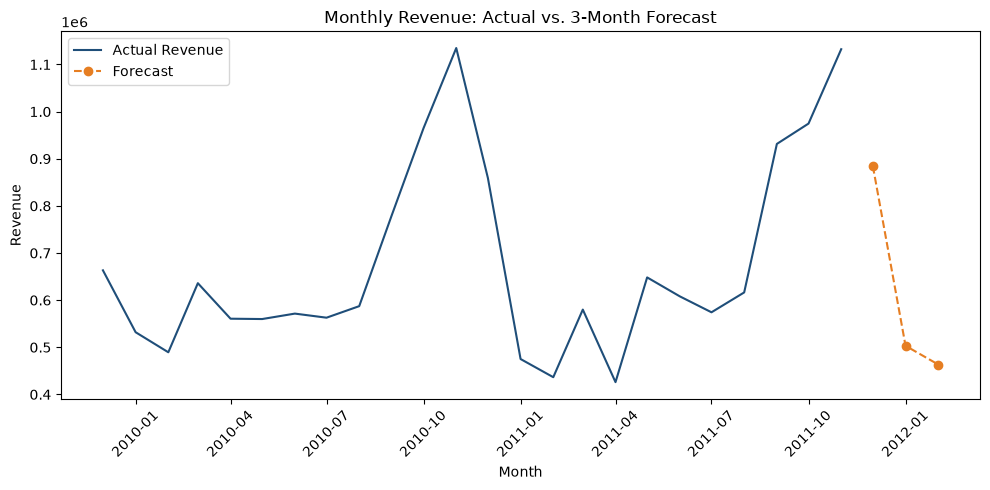

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts.index, ts.values, label='Actual Revenue', color='#1F4E79')
plt.plot(forecast.index, forecast.values, label='Forecast', color='#E67E22', linestyle='--', marker='o')
plt.title('Monthly Revenue: Actual vs. 3-Month Forecast')
plt.ylabel('Revenue')
plt.xlabel('Month')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../dashboard/q4_revenue_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
forecast_df = forecast.reset_index()
forecast_df.columns = ['Month', 'Forecasted_Revenue']
forecast_df.to_csv('../data/processed/revenue_forecast.csv', index=False)